<a href="https://colab.research.google.com/github/pran-pixel/NASSCOM1/blob/main/U3_Python_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

# 1A. ARRAY CREATION & SHAPE
# arange() builds a range; reshape() changes the shape without copying data
a = np.arange(6).reshape(2, 3)
print('Array a:\n', a)

print('shape :', a.shape)
print('ndim  :', a.ndim)
print('dtype :', a.dtype)

Array a:
 [[0 1 2]
 [3 4 5]]
shape : (2, 3)
ndim  : 2
dtype : int64


In [3]:
# 1B. SLICING & INDEXING

print('Column index 1 :', a[:, 1])
print('Row index 0    :', a[0, :])

# Boolean mask: keep only the elements that satisfy a condition
print('Elements > 2   :', a[a > 2])


Column index 1 : [1 4]
Row index 0    : [0 1 2]
Elements > 2   : [3 4 5]


In [4]:
# 1C. BROADCASTING
# Broadcasting lets NumPy combine arrays of different shapes without loops
row = np.array([10, 20, 30])   # shape (3,)
print('a + row (row added to every row of a):\n', a + row)


a + row (row added to every row of a):
 [[10 21 32]
 [13 24 35]]


In [5]:
b = np.ones((3, 2), dtype=int)   # shape (3, 2)
print('Matrix product a @ b:\n', a @ b)   # (2,3) @ (3,2) -> (2,2)

# Axis-wise reductions: axis=0 collapses rows, axis=1 collapses columns
print('Column-wise sum  (axis=0):', a.sum(axis=0))
print('Row-wise sum     (axis=1):', a.sum(axis=1))
print('Row-wise mean    (axis=1):', a.mean(axis=1))
print('Index of max per column  :', a.argmax(axis=0))


Matrix product a @ b:
 [[ 3  3]
 [12 12]]
Column-wise sum  (axis=0): [3 5 7]
Row-wise sum     (axis=1): [ 3 12]
Row-wise mean    (axis=1): [1. 4.]
Index of max per column  : [1 1 1]


In [6]:

# 1. Matrix product M @ N
import numpy as np

M = np.arange(1, 13).reshape(3, 4)
N = np.arange(1, 9).reshape(4, 2)

print("M:\n", M)
print("N:\n", N)

# 1. Matrix product M @ N
product = M @ N
print("\nMatrix Product (M @ N):\n", product)

# 2. Column-wise sum (axis=0) and row-wise mean (axis=1) of M
col_sum = np.sum(M, axis=0)
row_mean = np.mean(M, axis=1)

print("\nColumn-wise Sum:", col_sum)
print("Row-wise Mean:", row_mean)

# 3. Index of the max value in each row of M
max_index = np.argmax(M, axis=1)
print("\nIndex of Maximum Value in Each Row:", max_index)



M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

Matrix Product (M @ N):
 [[ 50  60]
 [114 140]
 [178 220]]

Column-wise Sum: [15 18 21 24]
Row-wise Mean: [ 2.5  6.5 10.5]

Index of Maximum Value in Each Row: [3 3 3]


In [8]:
import seaborn as sns

# 2A. LOAD & INSPECT
# Load the classic Titanic dataset (built into seaborn).
# In your own work this would be: pd.read_csv('titanic.csv')
df = sns.load_dataset('titanic')

print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
#  2B. HANDLE MISSING VALUES
# Count missing values per column
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head())

# Fill missing 'age' with the median (a common, robust strategy)
df['age'] = df['age'].fillna(df['age'].median())
print('\nMissing ages after fillna:', df['age'].isna().sum())


Missing values per column:
deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

Missing ages after fillna: 0


In [10]:
# 2C. GROUP BY A CATEGORY  (split -> apply -> combine)
# Average survival rate by passenger class
print('Survival rate by class:')
print(df.groupby('class', observed=True)['survived'].mean())

# Two-level grouping: survival by class AND sex
print('\nSurvival rate by class and sex:')
print(df.groupby(['class', 'sex'], observed=True)['survived'].mean())



Survival rate by class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

Survival rate by class and sex:
class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


In [11]:
import seaborn as sns

lab = sns.load_dataset('titanic')   # fresh copy to work on

# 1. Count missing values in 'embarked'
print("Missing values in 'embarked':", lab['embarked'].isnull().sum())

# 2. Fill missing 'embarked' with the mode
lab['embarked'].fillna(lab['embarked'].mode()[0], inplace=True)

# Verify that there are no missing values
print("Missing values after filling:", lab['embarked'].isnull().sum())

# 3. Mean fare grouped by 'sex'
mean_fare = lab.groupby('sex')['fare'].mean()
print("\nMean Fare Grouped by Sex:")
print(mean_fare)

Missing values in 'embarked': 2
Missing values after filling: 0

Mean Fare Grouped by Sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64


/tmp/ipykernel_957/1738973555.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lab['embarked'].fillna(lab['embarked'].mode()[0], inplace=True)


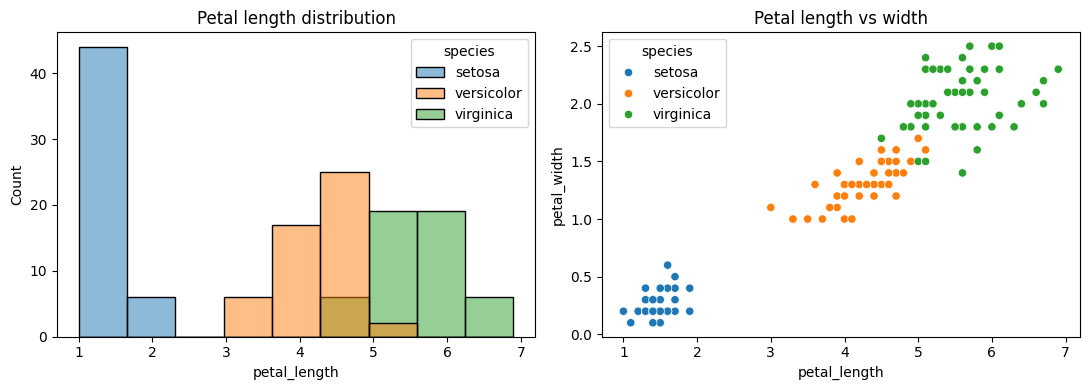

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3A. SUBPLOT COMPARISON  (Matplotlib)
iris = sns.load_dataset('iris')   # 150 flowers, 4 measurements, 3 species

# plt.subplots() makes a grid of axes for side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=iris, x='petal_length', hue='species', ax=axes[0])
axes[0].set_title('Petal length distribution')

sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', ax=axes[1])
axes[1].set_title('Petal length vs width')

plt.tight_layout()
plt.show()

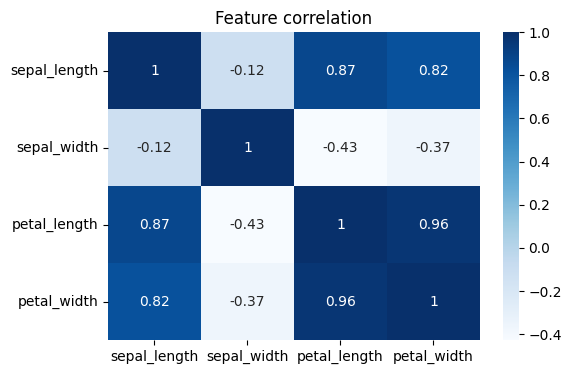

In [15]:
# 3B. CORRELATION HEATMAP  (Seaborn)
# .corr() on the numeric columns, visualised as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(iris.drop(columns='species').corr(),
            annot=True, cmap='Blues')
plt.title('Feature correlation')
plt.show()


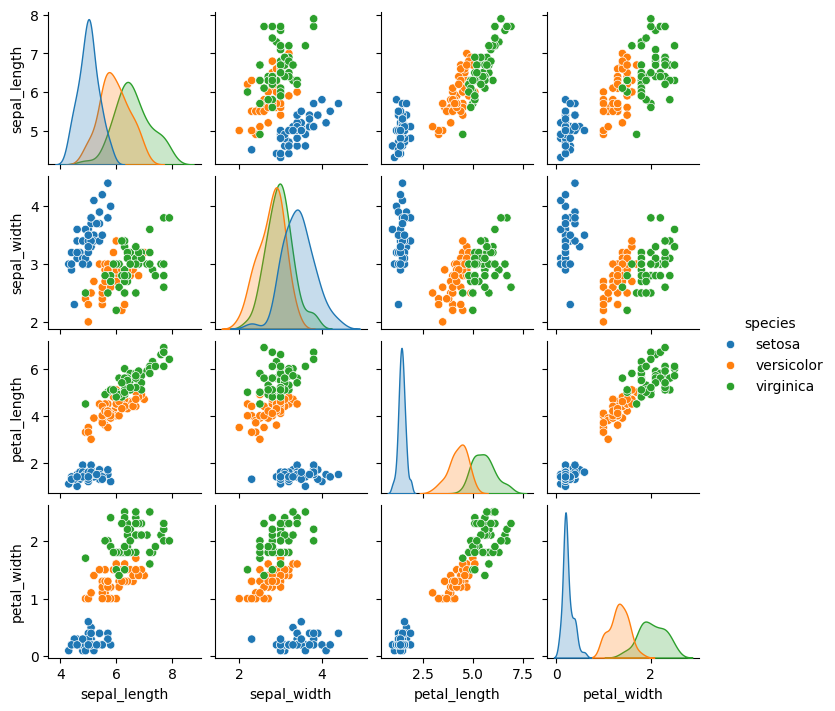

In [16]:
# 3C. PAIRPLOT  (every feature vs every feature)
# A pairplot draws scatter plots for all feature pairs at once,
# coloured by class -> a fast way to see how separable the classes are.
sns.pairplot(iris, hue='species', height=1.8)
plt.show()


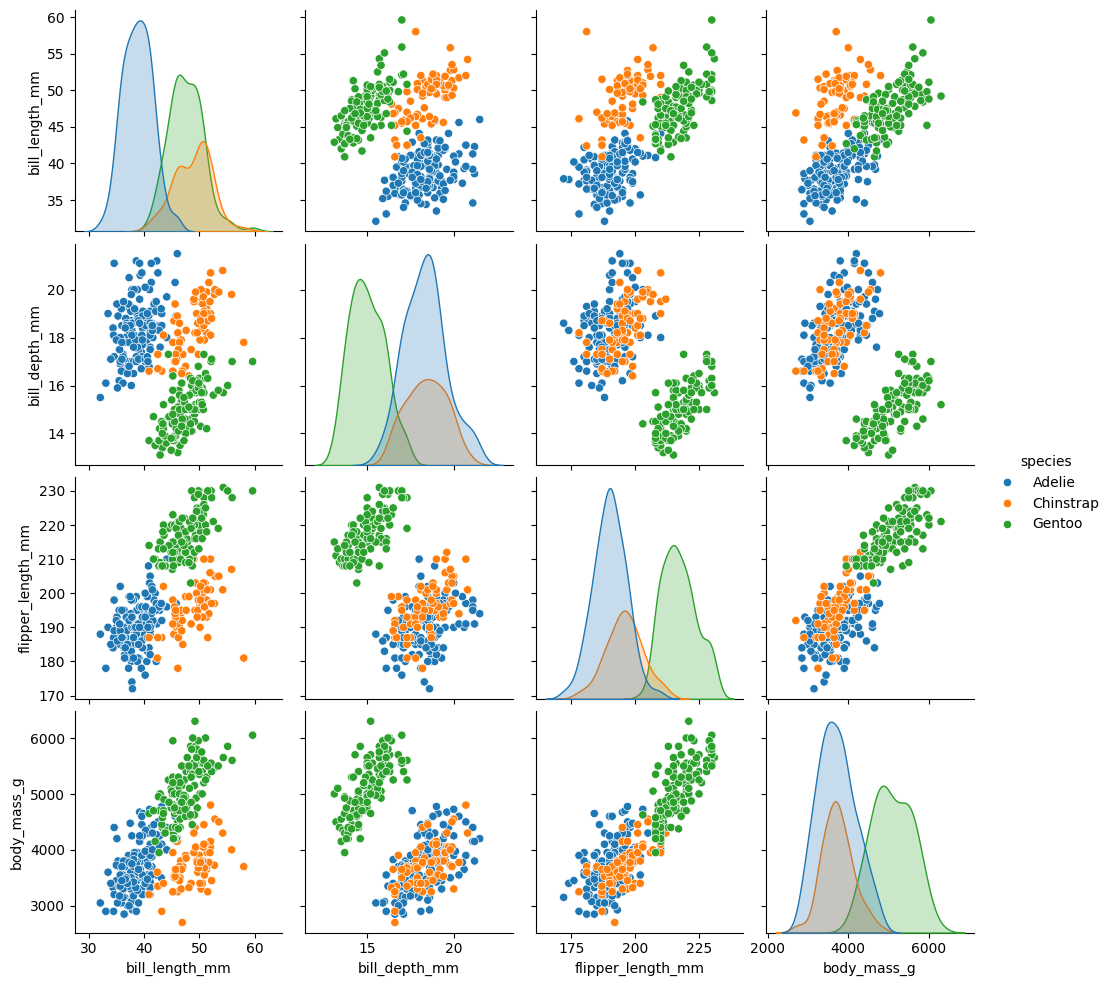

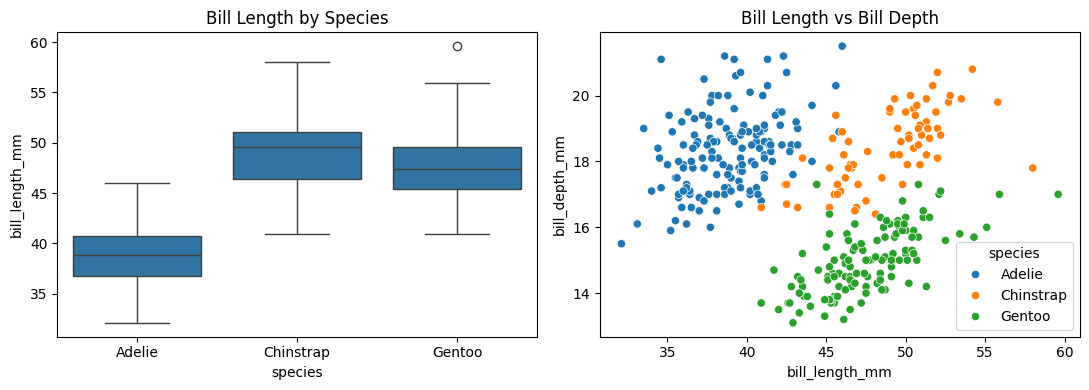

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

pen = sns.load_dataset('penguins')

# 1. Drop rows with missing values
pen = pen.dropna()

# 2. Pairplot coloured by 'species'
sns.pairplot(pen, hue='species')
plt.show()

# 3. 1x2 subplot: boxplot (left) + scatter (right)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot
sns.boxplot(x='species', y='bill_length_mm', data=pen, ax=axes[0])
axes[0].set_title("Bill Length by Species")

# Scatter Plot
sns.scatterplot(x='bill_length_mm',
                y='bill_depth_mm',
                hue='species',
                data=pen,
                ax=axes[1])
axes[1].set_title("Bill Length vs Bill Depth")

plt.tight_layout()
plt.show()

In [19]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
print('Features X:', X.shape, '| Target y:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape[0], 'samples | Test:', X_test.shape[0], 'samples')

Features X: (150, 4) | Target y: (150,)
Train: 120 samples | Test: 30 samples


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 3))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))

Accuracy: 0.9
Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])

pipe.fit(X_train, y_train)
print('Pipeline accuracy:', round(pipe.score(X_test, y_test), 3))

Pipeline accuracy: 0.933


In [24]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

Xb, yb = load_breast_cancer(return_X_y=True)
print('Breast cancer data:', Xb.shape)

X_train, X_test, y_train, y_test = train_test_split(
    Xb, yb,
    test_size=0.25,
    random_state=0,
    stratify=yb
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])


pipe.fit(X_train, y_train)

print('Test accuracy:', pipe.score(X_test, y_test))

Breast cancer data: (569, 30)
Test accuracy: 0.958041958041958


End-to-end Titanic survival accuracy: 0.793


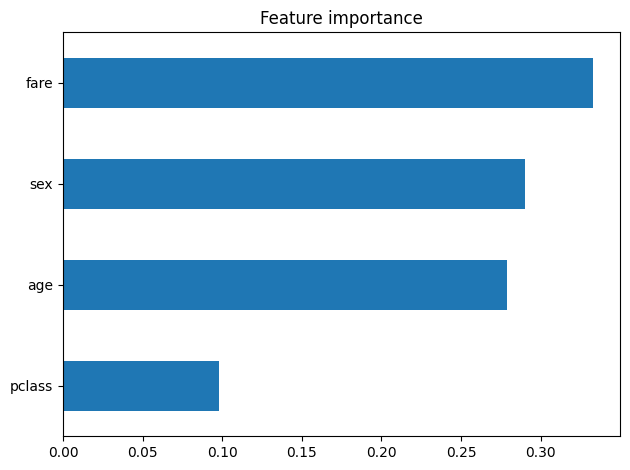

In [26]:
import pandas as pd
data = sns.load_dataset('titanic')

data = data[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex'] = np.where(data['sex'] == 'male', 0, 1)
data = data.dropna()


X = data.drop(columns='survived').values
y = data['survived'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
acc = accuracy_score(y_te, model.predict(X_te))


print('End-to-end Titanic survival accuracy:', round(acc, 3))

importances = pd.Series(model.feature_importances_,
                        index=data.drop(columns='survived').columns)
importances.sort_values().plot.barh(title='Feature importance')
plt.tight_layout(); plt.show()

In [27]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

iris = sns.load_dataset('iris')


X = iris.drop('species', axis=1)
y = iris['species']


encoder = LabelEncoder()
y = encoder.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)


model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print('Test accuracy:', accuracy)

Test accuracy: 0.9473684210526315
